# ECG diagnosis with Mamba blocks

This notebook builds an ECG diagnosis pipeline with PyTorch. This first section prepares the PhysioNet 12-lead ECG arrhythmia dataset for later Mamba-based modeling.

Dataset source: `https://physionet.org/files/ecg-arrhythmia/1.0.0/`

## 1. Imports and configuration

The code below is written to work with a local copy of the database.

In [25]:
from pathlib import Path
from typing import Callable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

try:
    import wfdb
except ImportError as exc:
    raise ImportError(
        "Install wfdb before running this notebook, e.g. `pip install wfdb`."
    ) from exc

RANDOM_STATE = 42
PHYSIONET_DB = "ecg-arrhythmia"
PHYSIONET_VERSION = "1.0.0"

# If you downloaded the dataset, set this to the directory containing WFDBRecords/.
# Example: DATA_ROOT = Path("physionet.org/files/ecg-arrhythmia/1.0.0")
DATA_ROOT = Path("physionet.org/files/ecg-arrhythmia")
CONDITIONS_MAPPING_PATH = DATA_ROOT / "ConditionNames_SNOMED-CT.csv"

BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## 2. Dataset loading

In [2]:
def is_dataset_available(data_root: Path) -> bool:
    return data_root.exists()


def iter_wfdb_record_paths(data_root: Path) -> List[Path]:
    """Return record paths without suffix using WFDBRecords/<group>/<subgroup>/<record> structure."""
    wfdb_root = data_root / "WFDBRecords"
    record_paths = []

    # Structure example: WFDBRecords/01/010/JS00001.hea
    for group_dir in wfdb_root.iterdir():
        if not group_dir.is_dir():
            continue
        for subgroup_dir in group_dir.iterdir():
            if not subgroup_dir.is_dir():
                continue

            subgroup_records_file = subgroup_dir / "RECORDS"
            if subgroup_records_file.exists():
                record_ids = [
                    line.strip()
                    for line in subgroup_records_file.read_text().splitlines()
                    if line.strip()
                ]
                record_paths.extend(subgroup_dir / record_id for record_id in record_ids)
            else:
                record_paths.extend(path.with_suffix("") for path in subgroup_dir.glob("*.hea"))

    return record_paths


def read_wfdb_header(data_root: Path, record_name: str):
    """Read only the lightweight WFDB header. Signals stay on disk until __getitem__."""
    try:
        return wfdb.rdheader(str(data_root / record_name))
    except:
        return None


if is_dataset_available(DATA_ROOT):
    record_paths = iter_wfdb_record_paths(DATA_ROOT)
    record_names = [str(record_path.relative_to(DATA_ROOT)) for record_path in record_paths]
    print(f"Found {len(record_names):,} WFDB records under {DATA_ROOT.resolve()}")
else:
    record_paths = []
    record_names = []
    print("ERROR: Local dataset was not found. Expected WFDBRecords/ and ConditionNames_SNOMED-CT.csv.")

Found 45,151 WFDB records under /home/sulyvahn/ecg/physionet.org/files/ecg-arrhythmia


## 3. Parse WFDB headers and build one-hot labels

Each `.hea` file contains comments with diagnostic SNOMED CT codes. The helper below searches common Challenge-style fields such as `Dx:` and maps those codes to readable names using `ConditionNames_SNOMED-CT.csv`.

In [3]:
class SNOMEDMapper:
    """Helper for SNOMED CT condition mappings and WFDB diagnosis extraction."""

    def __init__(self, source: Path):
        self.condition_df = pd.read_csv(source)
        self.condition_df.columns = [col.strip() for col in self.condition_df.columns]

        text_columns = ["Snomed_CT", "Full Name", "Acronym Name"]
        for col in text_columns:
            self.condition_df[col] = self.condition_df[col].astype(str).str.strip()

        # Defining indices for consistency
        self.condition_df["label_idx"] = np.arange(len(self.condition_df), dtype=np.int64)

    def code2name(self, code: str, use_acr_names: bool = False) -> str | None:
        """Convert SNOMED CT code to a readable condition name."""
        code = str(code).strip()
        name_col = "Acronym Name" if use_acr_names else "Full Name"
        match = self.condition_df.query("`Snomed_CT` == @code")[name_col]
        return None if match.empty else match.iloc[0]

    def code2idx(self, code: str) -> int | None:
        """Convert SNOMED CT code to label index."""
        code = str(code).strip()
        match = self.condition_df.query("`Snomed_CT` == @code")["label_idx"]
        return None if match.empty else int(match.iloc[0])

    def idx2name(self, idx: int, use_acr_names: bool = False) -> str | None:
        """Convert label index to condition name."""
        name_col = "Acronym Name" if use_acr_names else "Full Name"
        match = self.condition_df.loc[self.condition_df["label_idx"] == idx, name_col]
        return None if match.empty else match.iloc[0]

    def extract_codes(self, header) -> List[str]:
        """Extract SNOMED CT diagnosis codes from a WFDB header."""
        comments = header.comments
        codes = comments[2].split(': ')[1].split(',')
        return codes

    def extract_conditions(self, header, use_acr_names: bool = False) -> List[str]:
        """Extract readable condition names from a WFDB header."""
        no_match = []
        conditions = []
        for code in self.extract_codes(header):
            condition = self.code2name(code, use_acr_names=use_acr_names)
            if condition == None:
                no_match.append(code)
            else:
                conditions.append(condition)
        return conditions, no_match

    def onehot_from_codes(self, codes: List[str]) -> np.ndarray:
        """Create a multi-hot vector from SNOMED CT codes."""
        label = np.zeros(len(self.condition_df), dtype=np.float32)
        for code in codes:
            idx = self.code2idx(code)
            if idx is not None:
                label[idx] = 1.0
        return label

    def onehot_from_header(self, header) -> np.ndarray:
        """Create a multi-hot vector from a WFDB header."""
        return self.onehot_from_codes(self.extract_codes(header))


condition_mapper = SNOMEDMapper(CONDITIONS_MAPPING_PATH)
condition_mapper.condition_df.head()

,Acronym Name,Full Name,Snomed_CT,label_idx
0,1AVB,1 degree atrioventricular block,270492004,0
1,2AVB,2 degree atrioventricular block,195042002,1
2,2AVB1,2 degree atrioventricular block(Type one),54016002,2
3,2AVB2,2 degree atrioventricular block(Type two),28189009,3
4,3AVB,3 degree atrioventricular block,27885002,4


In [4]:
def build_label_table(
    record_names: Sequence[str],
    data_root: Path,
    mapper: SNOMEDMapper,
) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    """Build metadata and multi-hot labels from WFDB headers only."""
    rows = []
    labels = []

    progress = tqdm(record_names, desc="Reading WFDB headers", unit="header")

    for record_name in progress:
        progress.set_postfix_str(record_name)
        header = read_wfdb_header(data_root, record_name)

        if header is None:
            continue
        
        """
        During debugging the following number of evil corrupted entities were found: 98

        They have been successfully brought to justice. 

        ==================================================================
        try:
            _, _ = wfdb.rdsamp(str(data_root/record_name))
        except:
            print(f"Failed to read WFDB record: {data_root/record_name}")
            continue
        ==================================================================
        for code in no_match:
            if not code in condition_not_found:
                print(code)
                condition_not_found.append(code)
        ==================================================================
        """

        codes = mapper.extract_codes(header)
        conditions, _ = mapper.extract_conditions(header)
        rows.append(
            {
                "record_name": record_name,
                "n_samples": header.sig_len,
                "n_channels": header.n_sig,
                "fs": header.fs,
                "codes": codes,
                "conditions": conditions,
            }
        )
        labels.append(mapper.onehot_from_codes(codes))

    metadata = pd.DataFrame(rows)
    labels = np.vstack(labels).astype(np.float32) if labels else np.empty((0, len(mapper.condition_df)), dtype=np.float32)
    label_names = mapper.condition_df["Full Name"].tolist()
    return metadata, labels, label_names


metadata, labels, label_names = build_label_table(record_names, DATA_ROOT, condition_mapper)
print(f"Metadata rows: {len(metadata):,}")
print(f"Label matrix shape: {labels.shape}")
metadata.head()

Reading WFDB headers:   0%|          | 0/45151 [00:00<?, ?header/s]

Metadata rows: 45,054
Label matrix shape: (45054, 84)


,record_name,n_samples,n_channels,fs,codes,conditions
0,WFDBRecords/27/272/JS26600,5000,12,500,"[426177001, 164934002]","[Sinus Bradycardia, T wave Change]"
1,WFDBRecords/27/272/JS26601,5000,12,500,[426177001],[Sinus Bradycardia]
2,WFDBRecords/27/272/JS26602,5000,12,500,"[426177001, 55827005]","[Sinus Bradycardia, left ventricular hypertrophy]"
3,WFDBRecords/27/272/JS26603,5000,12,500,[426177001],[Sinus Bradycardia]
4,WFDBRecords/27/272/JS26604,5000,12,500,"[426177001, 164934002]","[Sinus Bradycardia, T wave Change]"


In [5]:
def remove_classes_below_total(
    metadata: pd.DataFrame,
    labels: np.ndarray,
    label_names: Sequence[str],
    mapper: SNOMEDMapper,
    min_total: int = 100,
) -> Tuple[pd.DataFrame, np.ndarray, List[str], SNOMEDMapper]:
    """Remove classes with fewer than min_total samples and drop records with no remaining labels."""
    class_totals = labels.sum(axis=0)
    keep_mask = class_totals >= min_total

    filtered_labels = labels[:, keep_mask]
    row_mask = filtered_labels.sum(axis=1) > 0

    filtered_metadata = metadata.loc[row_mask].copy().reset_index(drop=True)
    filtered_labels = filtered_labels[row_mask].astype(np.float32)
    filtered_label_names = [name for name, keep in zip(label_names, keep_mask) if keep]

    filtered_condition_df = mapper.condition_df.loc[keep_mask].copy().reset_index(drop=True)
    filtered_condition_df["label_idx"] = np.arange(len(filtered_condition_df), dtype=np.int64)

    kept_code_set = set(filtered_condition_df["Snomed_CT"].astype(str))
    kept_name_set = set(filtered_condition_df["Full Name"])
    filtered_metadata["codes"] = filtered_metadata["codes"].apply(
        lambda codes: [str(code) for code in codes if str(code) in kept_code_set]
    )
    filtered_metadata["conditions"] = filtered_metadata["conditions"].apply(
        lambda conditions: [condition for condition in conditions if condition in kept_name_set]
    )

    filtered_mapper = SNOMEDMapper.__new__(SNOMEDMapper)
    filtered_mapper.condition_df = filtered_condition_df

    return filtered_metadata, filtered_labels, filtered_label_names, filtered_mapper


metadata, labels, label_names, condition_mapper = remove_classes_below_total(
    metadata,
    labels,
    label_names,
    condition_mapper,
    min_total=1000,
)

print(f"Resulting number of classes: {len(label_names)}")

Resulting number of classes: 20


## 4. PyTorch dataset

The dataset class follows the standard PyTorch `Dataset` pattern: metadata and labels are prepared first, while ECG signals are loaded from disk inside `__getitem__`. A `DataLoader` then requests samples batch by batch at runtime.

In [28]:
class ECGNoiseAugmenter:
    """ECG noise using harmonic baseline wander and harmonic powerline interference."""

    def __init__(
        self,
        baseline_components: int = 50,
        baseline_delta_freq: float = 0.01,
        baseline_amplitude_range: tuple[float, float] = (0.001, 0.01),
        powerline_freq: float = 50.0,
        powerline_harmonics: int = 3,
        powerline_amplitude_range: tuple[float, float] = (0.001, 0.01),
    ):
        self.baseline_components = baseline_components
        self.baseline_delta_freq = baseline_delta_freq
        self.baseline_amplitude_range = baseline_amplitude_range
        self.powerline_freq = powerline_freq
        self.powerline_harmonics = powerline_harmonics
        self.powerline_amplitude_range = powerline_amplitude_range

    def __call__(self, signal: np.ndarray, fs: float) -> np.ndarray:
        noisy = signal.copy().astype(np.float32)
        n_samples, n_channels = noisy.shape
        t = np.arange(n_samples, dtype=np.float32) / float(fs)

        channel_scale = np.std(noisy, axis=0, keepdims=True) + 1e-6
        # add_baseline = np.random.random() < 0.6
        # add_powerline = np.random.random() < 0.6

        add_baseline = True
        add_powerline = True


        if add_baseline:
            baseline = np.zeros_like(noisy, dtype=np.float32)
            for k in range(1, self.baseline_components + 1):
                freq = k * self.baseline_delta_freq
                amplitude = np.random.uniform(
                    *self.baseline_amplitude_range,
                    size=(1, n_channels),
                )
                phase = np.random.uniform(0.0, 2.0 * np.pi, size=(1, n_channels))

                baseline += (
                    amplitude
                    * channel_scale
                    * np.cos(2.0 * np.pi * freq * t[:, None] + phase)
                ).astype(np.float32)
            
            noisy += baseline

        if add_powerline:
            powerline = np.zeros_like(noisy, dtype=np.float32)
            for k in range(1, self.powerline_harmonics + 1):
                freq = k * self.powerline_freq

                # Skip harmonics above Nyquist frequency.
                if freq >= 0.5 * float(fs):
                    continue

                amplitude = np.random.uniform(
                    *self.powerline_amplitude_range,
                    size=(1, n_channels),
                )
                phase = np.random.uniform(0.0, 2.0 * np.pi, size=(1, n_channels))

                powerline += (
                    amplitude
                    * channel_scale
                    * np.cos(2.0 * np.pi * freq * t[:, None] + phase)
                ).astype(np.float32)
        
            noisy += powerline

        return noisy.astype(np.float32)


class ECGArrhythmiaDataset(Dataset):
    """Disk-backed ECG dataset with one-hot / multi-hot labels for PyTorch."""

    def __init__(
        self,
        metadata: pd.DataFrame,
        onehot_labels: np.ndarray,
        data_root: Path,
        target_length: Optional[int] = 5000,
        standardize: bool = False,
        transform: Optional[Callable[[np.ndarray, float], np.ndarray]] = None,
        dtype: torch.dtype = torch.float32,
    ):
        if len(metadata) != len(onehot_labels):
            raise ValueError("metadata and onehot_labels must have the same length")
        if onehot_labels.ndim != 2:
            raise ValueError("onehot_labels must have shape (n_records, n_classes)")

        self.metadata = metadata.reset_index(drop=True).copy()
        self.onehot_labels = onehot_labels.astype(np.float32)
        self.data_root = Path(data_root)
        self.target_length = target_length
        self.standardize = standardize
        self.transform = transform
        self.dtype = dtype
        self.num_classes = self.onehot_labels.shape[1]

    def __len__(self) -> int:
        return len(self.metadata)

    def _load_signal(self, record_name: str, fs: float) -> np.ndarray:
        record_path = self.data_root / record_name
        try:
            signal, _ = wfdb.rdsamp(str(record_path))
        except Exception as exc:
            raise RuntimeError(f"Failed to read WFDB record: {record_path}") from exc
        # signal, _ = wfdb.rdsamp(str(record_path))  # shape: (samples, channels)
        signal = signal.astype(np.float32)

        if self.target_length is not None:
            signal = self._fix_length(signal, self.target_length)
        
        if self.transform is not None:
            signal = self.transform(signal, fs=fs)

        if self.standardize:
            mean = signal.mean(axis=0, keepdims=True)
            std = signal.std(axis=0, keepdims=True)
            signal = (signal - mean) / (std + 1e-6)

        return signal.T  # shape: (channels, samples)

    @staticmethod
    def _fix_length(signal: np.ndarray, target_length: int) -> np.ndarray:
        if signal.shape[0] == target_length:
            return signal
        if signal.shape[0] > target_length:
            return signal[:target_length]

        pad_width = target_length - signal.shape[0]
        return np.pad(signal, ((0, pad_width), (0, 0)), mode="constant")

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.metadata.iloc[index]
        x = self._load_signal(row["record_name"], fs=float(row["fs"]))
        y = self.onehot_labels[index]
        x = np.ascontiguousarray(x)
        y = np.ascontiguousarray(y)
        return (
            torch.from_numpy(x).to(dtype=self.dtype),
            torch.from_numpy(y.copy()).to(dtype=torch.float32),
        )


noise_transform = ECGNoiseAugmenter(
    baseline_components=5,
    baseline_delta_freq=0.1,       
    baseline_amplitude_range=(0.1, 1),
    powerline_freq=50.0,
    powerline_harmonics=3,
    powerline_amplitude_range=(0.001, 0.03),
)

original_full_dataset = ECGArrhythmiaDataset(metadata, labels, DATA_ROOT)
noisy_full_dataset = ECGArrhythmiaDataset(
    metadata,
    labels,
    DATA_ROOT,
    transform=noise_transform,
)
# full_dataset = ConcatDataset([original_full_dataset, noisy_full_dataset])

# full_dataset = ECGArrhythmiaDataset(metadata, labels, DATA_ROOT)
# augmented_full_dataset = ECGArrhythmiaDataset(metadata, labels, DATA_ROOT, transform=noise_transform)

print(f"Dataset size: {len(ConcatDataset([original_full_dataset, noisy_full_dataset])):,}")

Dataset size: 88,276


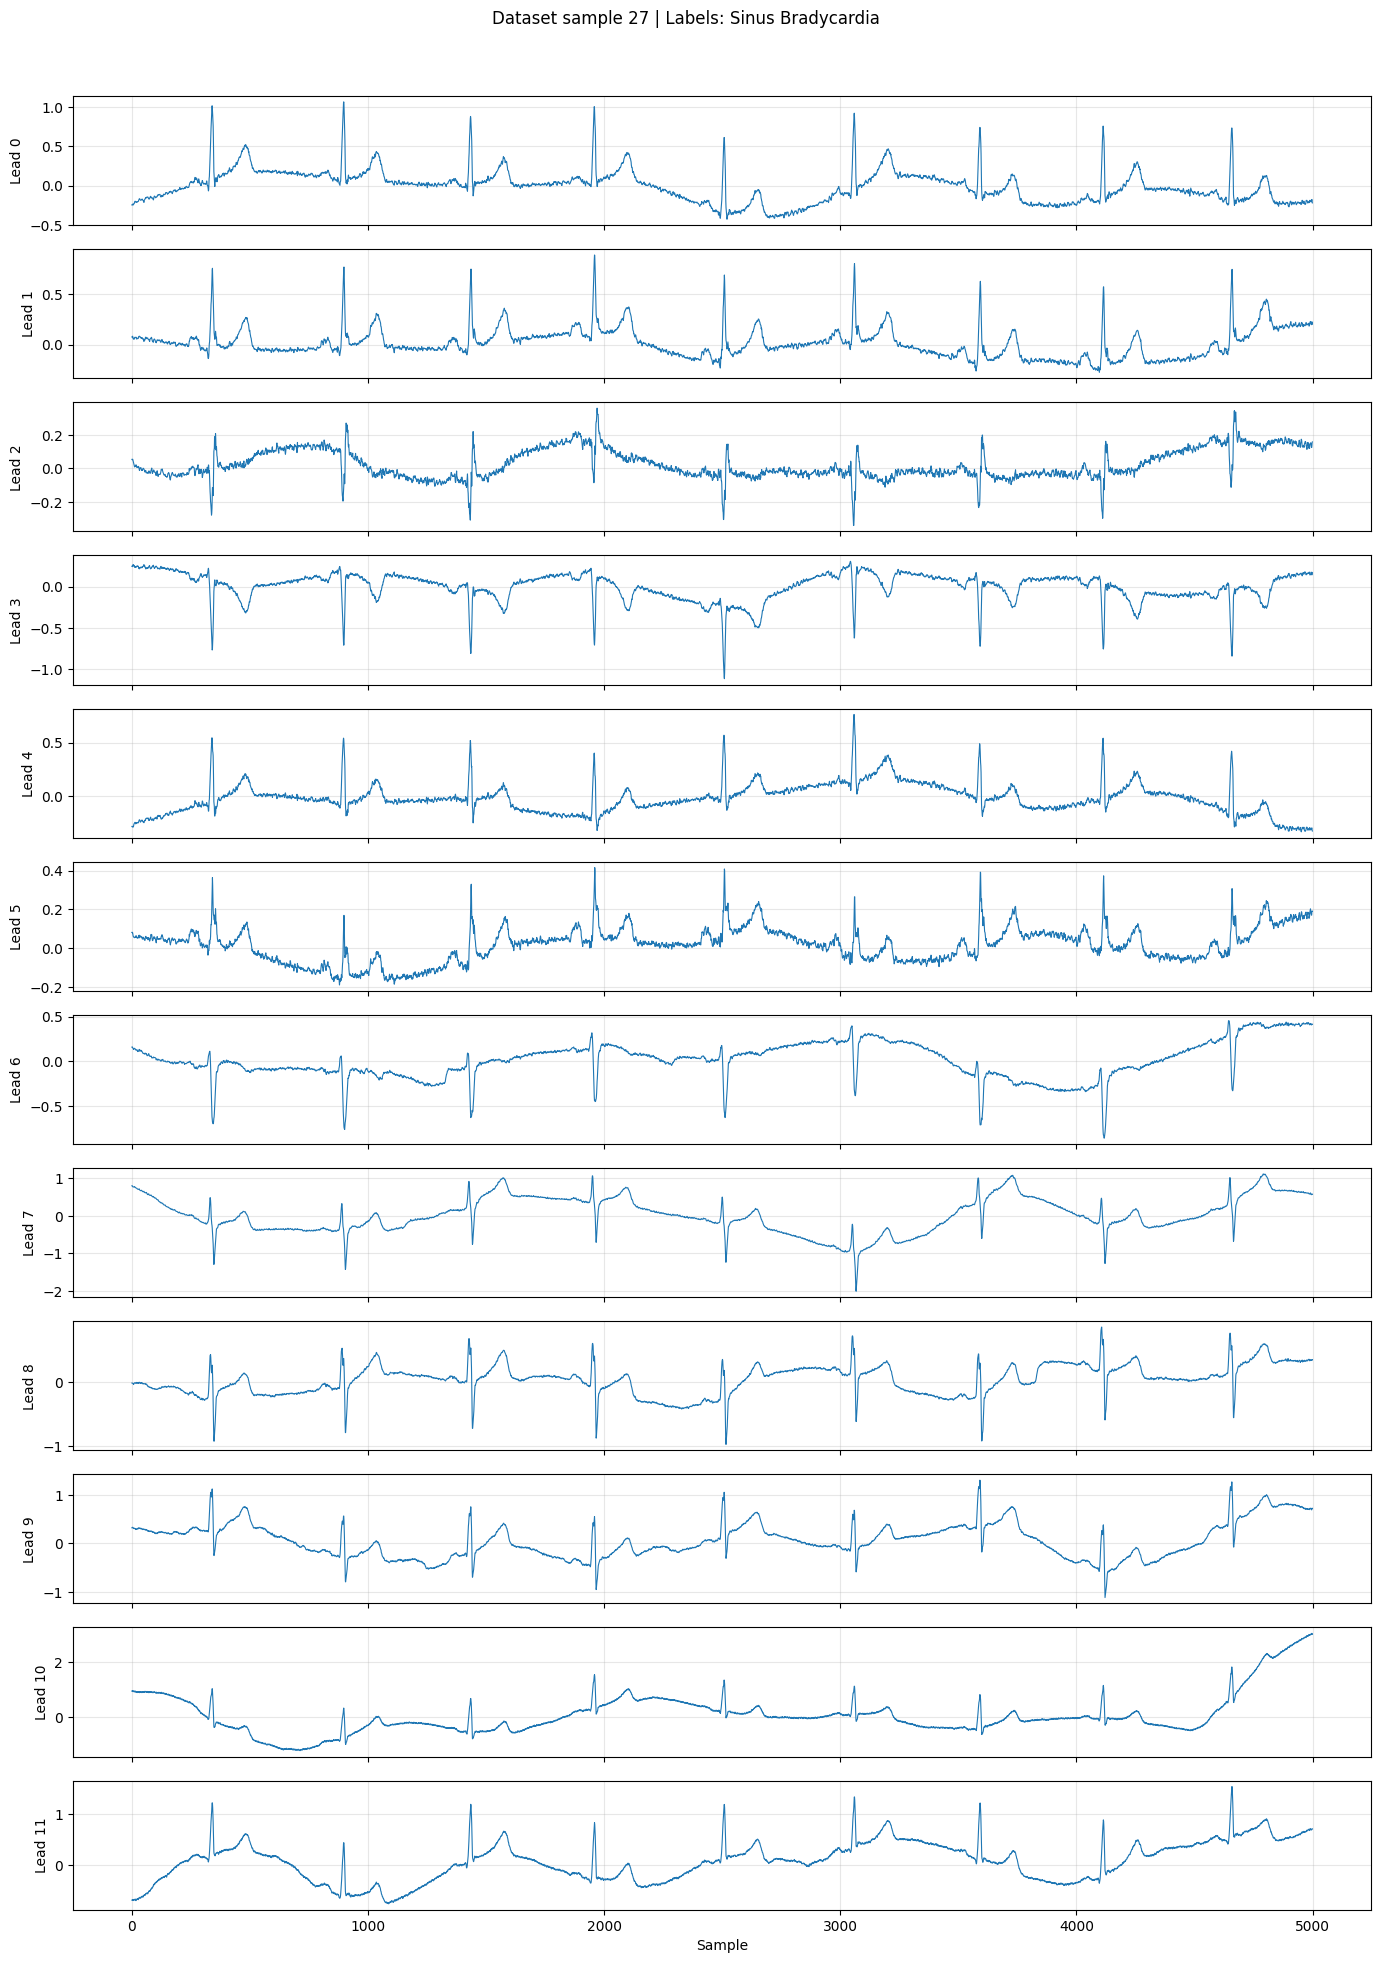

(<Figure size 1400x1920 with 12 Axes>,
 array([<Axes: ylabel='Lead 0'>, <Axes: ylabel='Lead 1'>,
        <Axes: ylabel='Lead 2'>, <Axes: ylabel='Lead 3'>,
        <Axes: ylabel='Lead 4'>, <Axes: ylabel='Lead 5'>,
        <Axes: ylabel='Lead 6'>, <Axes: ylabel='Lead 7'>,
        <Axes: ylabel='Lead 8'>, <Axes: ylabel='Lead 9'>,
        <Axes: ylabel='Lead 10'>,
        <Axes: xlabel='Sample', ylabel='Lead 11'>], dtype=object))

In [29]:
def plot_dataset_signal(
    dataset: Dataset,
    index: int = 0,
    channels: Sequence[int] | None = None,
    max_samples: int | None = None,
    fs: float | None = None,
    title: str | None = None,
):
    """Plot one ECG sample from a PyTorch dataset.

    Expects dataset[index] to return (x, y), where x has shape (channels, samples).
    Works with ECGArrhythmiaDataset, Subset, and ConcatDataset outputs.
    """
    import matplotlib.pyplot as plt

    x, y = dataset[index]
    x = x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)
    y = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)

    if x.ndim != 2:
        raise ValueError(f"Expected signal shape (channels, samples), got {x.shape}")

    n_channels, n_samples = x.shape
    if channels is None:
        channels = list(range(n_channels))
    else:
        channels = list(channels)

    if max_samples is not None:
        x = x[:, :max_samples]
        n_samples = x.shape[1]

    if fs is None:
        time = np.arange(n_samples)
        x_label = "Sample"
    else:
        time = np.arange(n_samples) / float(fs)
        x_label = "Time (s)"

    fig, axes = plt.subplots(
        len(channels),
        1,
        figsize=(14, max(2.0, 1.6 * len(channels))),
        sharex=True,
    )
    axes = np.atleast_1d(axes)

    for ax, channel in zip(axes, channels):
        ax.plot(time, x[channel], linewidth=0.8)
        ax.set_ylabel(f"Lead {channel}")
        ax.grid(True, alpha=0.3)

    active_labels = np.flatnonzero(y > 0.5)
    label_text = ", ".join(label_names[i] for i in active_labels) if "label_names" in globals() else str(active_labels.tolist())

    fig.suptitle(title or f"Dataset sample {index} | Labels: {label_text}", y=1.02)
    axes[-1].set_xlabel(x_label)
    plt.tight_layout()
    plt.show()

    return fig, axes

plot_dataset_signal(noisy_full_dataset, 27)


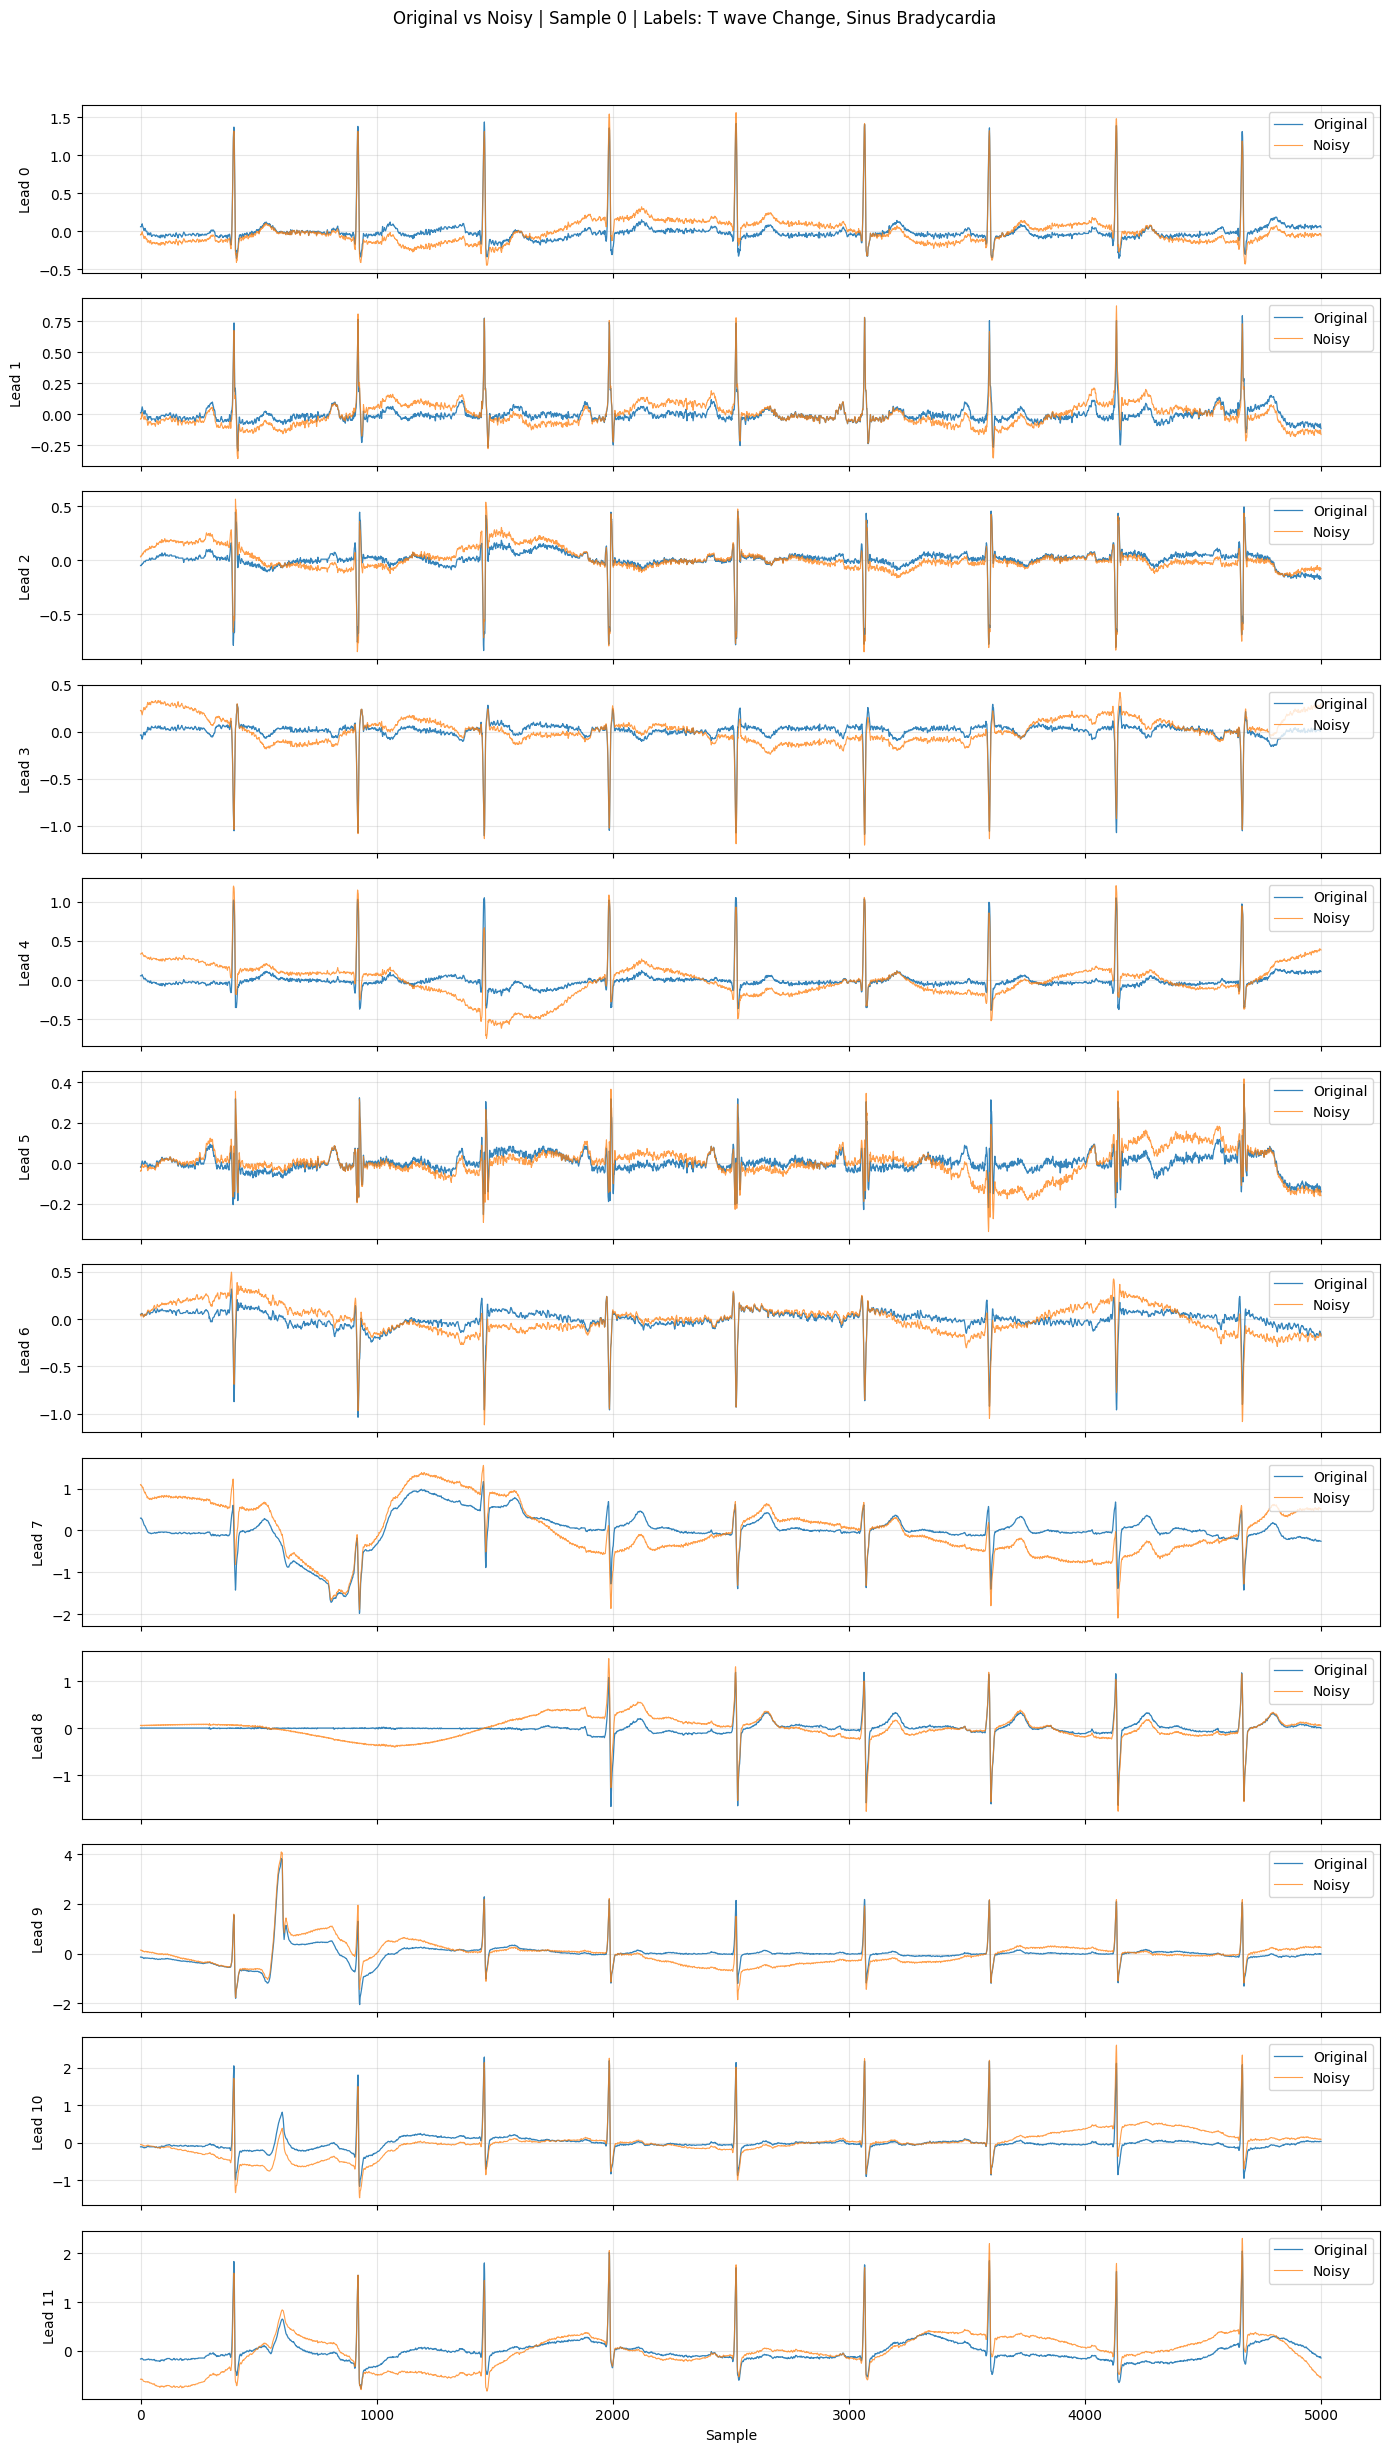

(<Figure size 1400x2400 with 12 Axes>,
 array([<Axes: ylabel='Lead 0'>, <Axes: ylabel='Lead 1'>,
        <Axes: ylabel='Lead 2'>, <Axes: ylabel='Lead 3'>,
        <Axes: ylabel='Lead 4'>, <Axes: ylabel='Lead 5'>,
        <Axes: ylabel='Lead 6'>, <Axes: ylabel='Lead 7'>,
        <Axes: ylabel='Lead 8'>, <Axes: ylabel='Lead 9'>,
        <Axes: ylabel='Lead 10'>,
        <Axes: xlabel='Sample', ylabel='Lead 11'>], dtype=object))

In [33]:
def plot_signal_comparison(
    original_dataset: Dataset,
    noisy_dataset: Dataset,
    index: int = 0,
    channels: Sequence[int] | None = None,
    max_samples: int | None = None,
    fs: float | None = None,
    title: str | None = None,
):
    """Compare original and noisy ECG signals from two aligned datasets.

    Expects both datasets to return the same record order.
    Each item should return (x, y), where x has shape (channels, samples).
    """
    import matplotlib.pyplot as plt

    x_clean, y_clean = original_dataset[index]
    x_noisy, y_noisy = noisy_dataset[index]

    x_clean = x_clean.detach().cpu().numpy() if torch.is_tensor(x_clean) else np.asarray(x_clean)
    x_noisy = x_noisy.detach().cpu().numpy() if torch.is_tensor(x_noisy) else np.asarray(x_noisy)
    y_clean = y_clean.detach().cpu().numpy() if torch.is_tensor(y_clean) else np.asarray(y_clean)

    if x_clean.shape != x_noisy.shape:
        raise ValueError(f"Shape mismatch: clean={x_clean.shape}, noisy={x_noisy.shape}")

    if x_clean.ndim != 2:
        raise ValueError(f"Expected signal shape (channels, samples), got {x_clean.shape}")

    n_channels, n_samples = x_clean.shape

    if channels is None:
        channels = list(range(n_channels))
    else:
        channels = list(channels)

    if max_samples is not None:
        x_clean = x_clean[:, :max_samples]
        x_noisy = x_noisy[:, :max_samples]
        n_samples = x_clean.shape[1]

    if fs is None:
        time = np.arange(n_samples)
        x_label = "Sample"
    else:
        time = np.arange(n_samples) / float(fs)
        x_label = "Time (s)"

    active_labels = np.flatnonzero(y_clean > 0.5)
    label_text = (
        ", ".join(label_names[i] for i in active_labels)
        if "label_names" in globals()
        else str(active_labels.tolist())
    )

    fig, axes = plt.subplots(
        len(channels),
        1,
        figsize=(14, max(2.5, 2.0 * len(channels))),
        sharex=True,
    )
    axes = np.atleast_1d(axes)

    for ax, channel in zip(axes, channels):
        ax.plot(time, x_clean[channel], linewidth=0.9, label="Original", alpha=0.9)
        ax.plot(time, x_noisy[channel], linewidth=0.8, label="Noisy", alpha=0.75)
        ax.set_ylabel(f"Lead {channel}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    fig.suptitle(
        title or f"Original vs Noisy | Sample {index} | Labels: {label_text}",
        y=1.02,
    )
    axes[-1].set_xlabel(x_label)
    plt.tight_layout()
    plt.show()

    return fig, axes

plot_signal_comparison(
    original_full_dataset,
    noisy_full_dataset,
)

## 5. Train/validation/test split and DataLoaders

For multi-label targets, exact stratification is non-trivial. The split below uses a reproducible random split. If class imbalance becomes severe, consider iterative multi-label stratification from `scikit-multilearn` or `iterative-stratification`.

In [9]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

def split_indices(
    labels: np.ndarray,
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_state: int = RANDOM_STATE,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Create reproducible train/validation/test indices with multilabel stratification."""
    labels = np.asarray(labels)

    if labels.ndim != 2:
        raise ValueError("labels must have shape (n_samples, n_classes)")

    n_samples = labels.shape[0]

    if n_samples == 0:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=int)

    indices = np.arange(n_samples)

    first_split = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_val_pos, test_pos = next(first_split.split(indices, labels))
    train_val_idx = indices[train_val_pos]
    test_idx = indices[test_pos]

    adjusted_val_size = val_size / (1.0 - test_size)

    second_split = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=adjusted_val_size,
        random_state=random_state,
    )

    train_pos, val_pos = next(
        second_split.split(
            train_val_idx,
            labels[train_val_idx],
        )
    )

    train_idx = train_val_idx[train_pos]
    val_idx = train_val_idx[val_pos]
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = split_indices(labels)

train_dataset = ConcatDataset([
    Subset(original_full_dataset, train_idx.tolist()),
    Subset(noisy_full_dataset, train_idx.tolist()),
])

val_dataset = Subset(original_full_dataset, val_idx.tolist())
test_dataset = Subset(original_full_dataset, test_idx.tolist())

In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Train: {len(train_dataset):,}")
print(f"Validation: {len(val_dataset):,}")
print(f"Test: {len(test_dataset):,}")

Train: 52,956
Validation: 8,835
Test: 8,825


In [11]:
def peek_batch(loader: DataLoader, device: torch.device = DEVICE) -> Tuple[torch.Tensor, torch.Tensor]:
    """Load one batch to verify the DataLoader output shapes."""
    x, y = next(iter(loader))
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    print(f"x: shape={tuple(x.shape)}, dtype={x.dtype}, device={x.device}")
    print(f"y: shape={tuple(y.shape)}, dtype={y.dtype}, device={y.device}")
    return x, y


if len(train_loader) > 0:
    batch_x, batch_y = peek_batch(train_loader)
else:
    print("Train loader is empty. Download the dataset or lower split constraints before peeking a batch.")

x: shape=(32, 12, 5000), dtype=torch.float32, device=cuda:0
y: shape=(32, 20), dtype=torch.float32, device=cuda:0


## 6. Model architecture
The model projects each ECG time step from 12 channels to a hidden dimension, processes the sequence with stacked `mamba-ssm` blocks, pools the sequence, and predicts one logit per diagnosis class. Because labels are one-hot/multi-hot vectors, training uses `BCEWithLogitsLoss`.

In [ ]:
import importlib
import sys

from mamba_ssm import Mamba2

class MambaECGBlock(torch.nn.Module):
    """Residual Mamba block for sequence features shaped as (batch, length, hidden)."""

    def __init__(
        self,
        d_model: int,
        d_state: int = 16,
        d_conv: int = 4,
        expand: int = 2,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.norm = torch.nn.LayerNorm(d_model)
        self.mamba = Mamba2(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.dropout(self.mamba(self.norm(x)))

class ECGConvBlock(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        conv_kernel: int = 3,
        conv_stride: int = 1,
        pool_kernel: int = 4,
        pool_stride: int = 2,
        groups: int = 1,
        padding: int = 0,
    ):
        super().__init__()
        self.conv = torch.nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=conv_kernel,
            stride=conv_stride,
            groups=groups,
            padding=padding,
        )
        # Group Norm because we want per-channel convolution
        self.norm = torch.nn.GroupNorm(groups, out_channels)
        self.activation = torch.nn.GELU()
        self.pool = torch.nn.MaxPool1d(
            kernel_size=pool_kernel,
            stride=pool_stride,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.norm(x)
        x = self.activation(x)
        x = self.pool(x)
        return x


class MambaECGClassifier(torch.nn.Module):
    """Mamba-based multi-label classifier for ECG signals."""

    def __init__(
        self,
        input_channels: int,
        num_classes: int,
        d_model: int = 128,
        n_layers: int = 4,
        d_state: int = 16,
        d_conv: int = 4,
        expand: int = 2,
        dropout: float = 0.3,
        conv_blocks_config: list[dict] | None = None,
    ):
        super().__init__()

        self.input_channels = input_channels
        self.d_model = d_model

        if conv_blocks_config is None:
            conv_blocks_config = [
                dict(conv_kernel=101, conv_stride=7, pool_kernel=4, pool_stride=1),
                dict(conv_kernel=15, conv_stride=2, pool_kernel=4, pool_stride=1),
            ]

        conv_blocks = []
        in_channels = input_channels
        out_channels = input_channels * d_model
        for block_config in conv_blocks_config:
            conv_blocks.append(
                ECGConvBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    conv_kernel=block_config.get("conv_kernel", 3),
                    conv_stride=block_config.get("conv_stride", 1),
                    pool_kernel=block_config.get("pool_kernel", 4),
                    pool_stride=block_config.get("pool_stride", 2),
                    groups=input_channels,
                    padding=block_config.get("padding", 0),
                )
            )
            in_channels = out_channels

        self.conv_blocks = torch.nn.Sequential(*conv_blocks)

        self.blocks = torch.nn.ModuleList(
            [
                MambaECGBlock(
                    d_model=d_model,
                    d_state=d_state,
                    d_conv=d_conv,
                    expand=expand,
                    dropout=dropout,
                )
                for _ in range(n_layers)
            ]
        )

        self.lead_embedding = torch.nn.Parameter(
            torch.zeros(1, input_channels, 1, d_model)
        )

        torch.nn.init.normal_(self.lead_embedding, std=0.02)

        self.channel_attention_query = torch.nn.Parameter(torch.zeros(1, 1, d_model))
        self.channel_attention = torch.nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=1,
            batch_first=True,
        )

        self.norm = torch.nn.LayerNorm(d_model)

        self.classifier = torch.nn.Sequential(
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_model, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, channels, samples = x.shape

        x = self.conv_blocks(x)
        
        # Receiveing per-lead features
        samples = x.shape[-1]

        x = x.reshape(batch_size, channels, self.d_model, samples)
        
        # Working with each lead in parallel (as if they are parts of a batch)
        x = x.permute(0, 1, 3, 2)
        x = x.reshape(batch_size * channels, samples, self.d_model)

        for block in self.blocks:
            x = block(x)

        # Restoring the leads dim
        x = x.reshape(batch_size, channels, samples, self.d_model)

        # # Fuse leads
        # x = x.permute(0, 2, 1, 3)
        # x = x.reshape(batch_size * samples, 12, self.d_model)

        x = x.mean(2)

        query = self.channel_attention_query.expand(batch_size, -1, -1)
        x, _ = self.channel_attention(query, x, x)
        
        x = x.squeeze(1)
        x = self.norm(x)
        
        return self.classifier(x)
    

input_channels = int(metadata["n_channels"].iloc[0])
num_classes = labels.shape[1]

model = MambaECGClassifier(
    input_channels=input_channels,
    num_classes=num_classes,
    d_model=64,
    n_layers=2,
).to(DEVICE)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MambaECGClassifier(
  (conv_blocks): Sequential(
    (0): ECGConvBlock(
      (conv): Conv1d(12, 768, kernel_size=(101,), stride=(7,), groups=12)
      (norm): GroupNorm(12, 768, eps=1e-05, affine=True)
      (activation): GELU(approximate='none')
      (pool): MaxPool1d(kernel_size=4, stride=1, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ECGConvBlock(
      (conv): Conv1d(768, 768, kernel_size=(15,), stride=(2,), groups=12)
      (norm): GroupNorm(12, 768, eps=1e-05, affine=True)
      (activation): GELU(approximate='none')
      (pool): MaxPool1d(kernel_size=4, stride=1, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (blocks): ModuleList(
    (0-1): 2 x MambaECGBlock(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mamba): Mamba2(
        (in_proj): Linear(in_features=64, out_features=290, bias=False)
        (conv1d): Conv1d(160, 160, kernel_size=(4,), stride=(1,), padding=(3,), groups=160)
        (act): SiLU()
        (norm): RMSNorm()
   

## 7. Training loop

The training loop uses `BCEWithLogitsLoss` for multi-label one-hot targets. The progress bar shows running training loss, and the graph tracks train/validation loss after each epoch.

In [13]:
import matplotlib.pyplot as plt

EPOCHS = 10
LEARNING_RATE = 1e-4
GRAD_CLIP_NORM = 1.0
ACCUMULATION_STEPS = 1
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

model = MambaECGClassifier(
    input_channels=input_channels,
    num_classes=num_classes,
    d_model=64,
    n_layers=2,
).to(DEVICE)

train_labels = torch.as_tensor(labels[train_idx], dtype=torch.float32)

positive_counts = train_labels.sum(dim=0)
negative_counts = train_labels.shape[0] - positive_counts

pos_weight = negative_counts / positive_counts.clamp(min=1.0)
pos_weight = pos_weight.clamp(max=20.0).to(DEVICE)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


def train_one_epoch(
    model: torch.nn.Module,
    loader: DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    accumulation_steps: int,
    grad_clip_norm: float | None = None,
) -> float:
    model.train()
    running_loss = 0.0
    n_samples = 0
    
    optimizer.zero_grad(set_to_none=True)
    for step, (x, y) in enumerate(loader, 1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size
        
        loss /= accumulation_steps
        loss.backward()

        if step % accumulation_steps == 0:
            # if grad_clip_norm is not None:
                # torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    if step % accumulation_steps != 0:
        # if grad_clip_norm is not None:
            # torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def evaluate(
    model: torch.nn.Module,
    loader: DataLoader,
    criterion: torch.nn.Module,
    device: torch.device,
) -> float:
    model.eval()
    running_loss = 0.0
    n_samples = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(n_samples, 1)


history = {"train_loss": [], "val_loss": [], "lr": []}
best_val_loss = float("inf")
best_epoch = 0
best_state = None
epochs_without_improvement = 0

## 8. Hyperparameter grid selection

Run several Conv + Mamba configurations, stop each one early, compare validation loss, and keep the best model.

In [39]:
from copy import deepcopy
import gc

HYPERPARAM_GRID = [
    {
        "name": "d128_l2_k101_10_k15",
        "d_model": 128,
        "n_layers": 2,
        "d_state": 16,
        "d_conv": 4,
        "expand": 2,
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "conv_blocks_config": [
            dict(conv_kernel=101, conv_stride=10, pool_kernel=4, pool_stride=2),
            dict(conv_kernel=15, conv_stride=1, pool_kernel=4, pool_stride=1),
        ],
    },
    # {
    #     "name": "d32_l1_k101_3_k13",
    #     "d_model": 32,
    #     "n_layers": 1,
    #     "d_state": 16,
    #     "d_conv": 4,
    #     "expand": 2,
    #     "dropout": 0.3,
    #     "lr": 5e-4,
    #     "weight_decay": 1e-4,
    #     "conv_blocks_config": [
    #         dict(conv_kernel=101, conv_stride=3, pool_kernel=8, pool_stride=2),
    #         dict(conv_kernel=13, conv_stride=1, pool_kernel=4, pool_stride=2),
    #     ],
    # },
    # {
    #     "name": "d32_l1_k101_3",
    #     "d_model": 32,
    #     "n_layers": 1,
    #     "d_state": 16,
    #     "d_conv": 4,
    #     "expand": 2,
    #     "dropout": 0.3,
    #     "lr": 5e-4,
    #     "weight_decay": 1e-4,
    #     "conv_blocks_config": [
    #         dict(conv_kernel=101, conv_stride=3, pool_kernel=8, pool_stride=2),
    #     ],
    # },
]


def make_model_from_config(config: dict) -> MambaECGClassifier:
    return MambaECGClassifier(
        input_channels=input_channels,
        num_classes=num_classes,
        d_model=config["d_model"],
        n_layers=config["n_layers"],
        d_state=config["d_state"],
        d_conv=config["d_conv"],
        expand=config["expand"],
        dropout=config["dropout"],
        conv_blocks_config=config["conv_blocks_config"],
    ).to(DEVICE)


def run_one_grid_experiment(
    config: dict,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: torch.nn.Module,
    max_epochs: int = 20,
    patience: int = 4,
    min_delta: float = 0,
) -> tuple[dict, torch.nn.Module]:
    candidate_model = make_model_from_config(config)
    optimizer = torch.optim.AdamW(
        candidate_model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=config["lr"] * 0.1)

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    bad_epochs = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    pbar = tqdm(range(1, max_epochs + 1), desc="Training Progress")

    for epoch in pbar:
        train_loss = train_one_epoch(
            model=candidate_model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            accumulation_steps=ACCUMULATION_STEPS,
            grad_clip_norm=GRAD_CLIP_NORM,
        )
        val_loss = evaluate(
            model=candidate_model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
        )

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = deepcopy(candidate_model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(
            f'{config["name"]} | epoch {epoch:02d}/{max_epochs} | '
            f'train={train_loss:.5f} | val={val_loss:.5f} | '
            f'best={best_val_loss:.5f} @ {best_epoch:02d} | lr={current_lr:.2e}'
        )

        if bad_epochs >= patience:
            break

    if best_state is not None:
        candidate_model.load_state_dict(best_state)

    result = {
        "name": config["name"],
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_ran": len(history["val_loss"]),
        "history": history,
        "d_model": config["d_model"],
        "n_layers": config["n_layers"],
        "d_state": config["d_state"],
        "d_conv": config["d_conv"],
        "expand": config["expand"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "conv_blocks_config": config["conv_blocks_config"],
    }
    return result, candidate_model


def run_hyperparameter_grid(
    hyperparam_grid: list[dict],
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: torch.nn.Module,
    max_epochs: int = 20,
    patience: int = 4,
) -> tuple[pd.DataFrame, torch.nn.Module, dict]:
    results = []
    best_model = None
    best_config = None
    best_val_loss = float("inf")

    for i, config in enumerate(hyperparam_grid, 1):
        print("=" * 100)
        print(f'Experiment {i}/{len(hyperparam_grid)}: {config["name"]}')
        print("=" * 100)

        result, candidate_model = run_one_grid_experiment(
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            max_epochs=max_epochs,
            patience=patience,
        )
        results.append(result)

        if result["best_val_loss"] < best_val_loss:
            if best_model is not None:
                del best_model
            best_val_loss = result["best_val_loss"]
            best_model = candidate_model
            best_config = config
        else:
            del candidate_model

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    results_df = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)
    return results_df, best_model, best_config


grid_results, best_grid_model, best_grid_config = run_hyperparameter_grid(
    hyperparam_grid=HYPERPARAM_GRID,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    max_epochs=30,
    patience=6,
)

display(grid_results[["name", "best_val_loss", "best_epoch", "epochs_ran", "d_model", "n_layers", "d_state", "d_conv", "expand", "dropout", "lr"]])
model = best_grid_model
print("Best config:", best_grid_config)

Experiment 1/1: d128_l2_k101_10_k15


Training Progress:   0%|          | 0/30 [00:00<?, ?it/s]

d128_l2_k101_10_k15 | epoch 01/30 | train=0.71889 | val=0.54860 | best=0.54860 @ 01 | lr=9.98e-05
d128_l2_k101_10_k15 | epoch 02/30 | train=0.56034 | val=0.48730 | best=0.48730 @ 02 | lr=9.90e-05
d128_l2_k101_10_k15 | epoch 03/30 | train=0.50568 | val=0.44993 | best=0.44993 @ 03 | lr=9.78e-05
d128_l2_k101_10_k15 | epoch 04/30 | train=0.47422 | val=0.44670 | best=0.44670 @ 04 | lr=9.61e-05


KeyboardInterrupt: 

In [37]:
gc.collect()
torch.cuda.empty_cache()

In [54]:
torch.save(model.state_dict(), 'models/classifier_aug_128.pth')

In [20]:
model = make_model_from_config(
    {
        "name": "d160_l2_k101_3_k21",
        "d_model": 128,
        "n_layers": 2,
        "d_state": 16,
        "d_conv": 4,
        "expand": 2,
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "conv_blocks_config": [
            dict(conv_kernel=101, conv_stride=10, pool_kernel=4, pool_stride=2),
            dict(conv_kernel=15, conv_stride=1, pool_kernel=4, pool_stride=1),
        ],
    },
)
model.load_state_dict(
        torch.load(
        'models/classifier_aug_128.pth'
    )
)

<All keys matched successfully>

## 9. Metrics and confusion matrix

Evaluate the trained model on the test set, compute multi-label classification metrics, and visualize the aggregated confusion matrix as a heatmap.

,metric,value
0,subset_accuracy,0.518980
1,hamming_loss,0.043105
2,micro_precision,0.708512
3,micro_recall,0.848704
4,micro_f1,0.772297
5,macro_precision,0.622211
6,macro_recall,0.788083
7,macro_f1,0.680527
8,weighted_f1,0.793128


,class,support,precision,recall,f1
11,Sinus Bradycardia,3305,0.977367,0.993041,0.985142
14,Sinus Tachycardia,1447,0.974035,0.959226,0.966574
12,Sinus Rhythm,1622,0.888889,0.937115,0.912365
19,pacemaker rythm,235,0.940594,0.808511,0.869565
15,Atrial Flutter,1609,0.779927,0.927284,0.847246
4,left ventricular hypertrophy,1076,0.735071,0.812268,0.771744
18,complete right bundle branch block,218,0.601156,0.954128,0.737589
0,1 degree atrioventricular block,227,0.617647,0.832599,0.709193
1,Axis left shift,309,0.572632,0.880259,0.693878
9,T wave Change,1407,0.688593,0.587775,0.634202


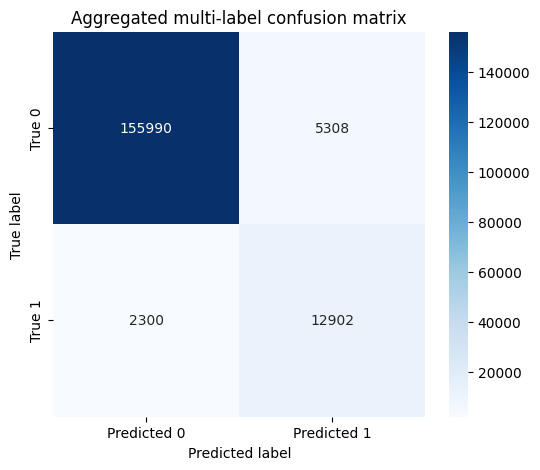

,class,tn,fp,fn,tp
11,Sinus Bradycardia,5444,76,23,3282
12,Sinus Rhythm,7013,190,102,1520
15,Atrial Flutter,6795,421,117,1492
14,Sinus Tachycardia,7341,37,59,1388
4,left ventricular hypertrophy,7434,315,202,874
9,T wave Change,7044,374,580,827
8,ST change,7549,431,315,530
16,Sinus Irregularity,7838,480,53,454
10,T wave opposite,7913,338,190,384
13,Atrial Fibrillation,7509,960,51,305


In [22]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
import seaborn as sns


@torch.no_grad()
def collect_predictions(
    model: torch.nn.Module,
    loader: DataLoader,
    device: torch.device,
    threshold: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return true labels, predicted labels, and predicted probabilities."""
    model.eval()
    y_true_batches = []
    y_prob_batches = []

    for x, y in tqdm(loader, desc="Collecting predictions", unit="batch"):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probabilities = torch.sigmoid(logits)

        y_true_batches.append(y.cpu().numpy())
        y_prob_batches.append(probabilities.cpu().numpy())

    y_true = np.vstack(y_true_batches).astype(np.int32)
    y_prob = np.vstack(y_prob_batches)
    y_pred = (y_prob >= threshold).astype(np.int32)
    return y_true, y_pred, y_prob


THRESHOLD = 0.8

y_true, y_pred, y_prob = collect_predictions(
    model=model,
    loader=test_loader,
    device=DEVICE,
    threshold=THRESHOLD,
)

metrics = {
    "subset_accuracy": accuracy_score(y_true, y_pred),
    "hamming_loss": hamming_loss(y_true, y_pred),
    "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
    "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
    "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
    "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

metrics_df = pd.DataFrame(metrics.items(), columns=["metric", "value"])
display(metrics_df)

per_class_metrics = pd.DataFrame(
    {
        "class": label_names,
        "support": y_true.sum(axis=1) if False else y_true.sum(axis=0),
        "precision": precision_score(y_true, y_pred, average=None, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=None, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=None, zero_division=0),
    }
).sort_values("f1", ascending=False)

display(per_class_metrics)

# Multi-label confusion matrix returns one 2x2 matrix per class:
# [[true_negative, false_positive],
#  [false_negative, true_positive]]
ml_conf_mats = multilabel_confusion_matrix(y_true, y_pred)
aggregate_confusion = ml_conf_mats.sum(axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(
    aggregate_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["True 0", "True 1"],
)
plt.title("Aggregated multi-label confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

per_class_confusion = pd.DataFrame(
    {
        "class": label_names,
        "tn": ml_conf_mats[:, 0, 0],
        "fp": ml_conf_mats[:, 0, 1],
        "fn": ml_conf_mats[:, 1, 0],
        "tp": ml_conf_mats[:, 1, 1],
    }
).sort_values("tp", ascending=False)

display(per_class_confusion)